# 07 — Combined Image Types Clustering (Masked Transverse + Coronal)

This notebook combines two per-image-type PCA feature sets:

- **`pca_masked_tra.csv`** — 110 PCA components from brain-masked transverse MRI slices
- **`pca_cor.csv`** — 110 PCA components from coronal MRI slices

The two sets are merged on `patient_id` by column concatenation, producing a
220-feature matrix per patient.  Clustering is performed with Euclidean distance
via `SampleDistClustering` and evaluated against CDR labels.

## Cell 2 — Install dependencies

In [1]:
import subprocess, sys

def run_pip(*args):
    cmd = [sys.executable, "-m", "pip", "install", "--quiet"] + list(args)
    r   = subprocess.run(cmd, capture_output=True, text=True)
    tag = args[-1]
    if r.returncode == 0:
        print(f"  OK    {tag}")
    else:
        print(f"  FAIL  {tag}")
        print(r.stderr[-600:] if r.stderr else "(no stderr)")

run_pip("--no-deps", "db-robust-clust==0.1.10")
for pkg in ["kmedoids", "robust-mixed-dist", "openpyxl"]:
    run_pip(pkg)
print("Done.")

  OK    db-robust-clust==0.1.10
  OK    kmedoids
  OK    robust-mixed-dist
  OK    openpyxl
Done.


## Cell 3 — Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kmedoids
from db_robust_clust.models import SampleDistClustering
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

print("All imports successful.")

All imports successful.


## Cell 4 — Load and merge PCA files

Both files are loaded and merged on `patient_id` using an inner join,
which concatenates the 110 masked-transverse columns and the 110 coronal
columns side by side.  The result is saved as `pca_masked_tra_cor_combined.csv`.

In [3]:
DATA_DIR = r"C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data"
NB_DIR   = os.path.join(DATA_DIR, "notebooks")

df_masked = pd.read_csv(os.path.join(NB_DIR, "pca_masked_tra.csv"))
df_cor    = pd.read_csv(os.path.join(NB_DIR, "pca_cor.csv"))

print(f"pca_masked_tra.csv : {df_masked.shape}")
print(f"pca_cor.csv        : {df_cor.shape}")

# Merge by concatenating columns (inner join keeps only shared patient IDs)
df_combined = df_masked.merge(df_cor, on="patient_id", how="inner")

print(f"\nCombined matrix    : {df_combined.shape}")
print(f"  rows             : {df_combined.shape[0]}  (patients)")
print(f"  cols             : {df_combined.shape[1]}  (patient_id + {df_combined.shape[1]-1} PCA features)")
print(f"  first 4 cols     : {list(df_combined.columns[:4])}")
print(f"  last  4 cols     : {list(df_combined.columns[-4:])}")

out_path = os.path.join(NB_DIR, "pca_masked_tra_cor_combined.csv")
df_combined.to_csv(out_path, index=False)
print(f"\nSaved to: {out_path}")

pca_masked_tra.csv : (416, 111)
pca_cor.csv        : (416, 111)

Combined matrix    : (416, 221)
  rows             : 416  (patients)
  cols             : 221  (patient_id + 220 PCA features)
  first 4 cols     : ['patient_id', 'masked_tra_PC1', 'masked_tra_PC2', 'masked_tra_PC3']
  last  4 cols     : ['cor_PC107', 'cor_PC108', 'cor_PC109', 'cor_PC110']

Saved to: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\pca_masked_tra_cor_combined.csv


## Cell 5 — Clustering setup

Prepare the feature matrix `X` and align CDR labels for evaluation.
CDR is **not** included in `X` — it is used only after clustering.

In [4]:
patient_ids = df_combined["patient_id"].values
X           = df_combined.drop(columns=["patient_id"]).to_numpy(dtype=np.float64)
print(f"Feature matrix X  : {X.shape}  (patients × PCA features)")

# ── Load clinical data for CDR evaluation ────────────────────────────────────
df_clin = pd.read_excel(
    os.path.join(NB_DIR, "oasis_cross-sectional-5708aa0a98d82080.xlsx")
)
if "ID" in df_clin.columns:
    df_clin = df_clin.rename(columns={"ID": "patient_id"})

# Strip _MR1/_MR2 suffix so IDs match the PCA files
df_clin["patient_id"] = df_clin["patient_id"].str.replace(r"_MR\d+$", "", regex=True)

# Deduplicate: keep row with CDR value where a patient has two sessions
df_clin = (
    df_clin
    .sort_values("CDR", na_position="last")
    .drop_duplicates(subset="patient_id", keep="first")
    .reset_index(drop=True)
)

cdr_series = df_clin.set_index("patient_id")["CDR"].reindex(patient_ids)
n_with_cdr = int(cdr_series.notnull().sum())
print(f"Patients with CDR : {n_with_cdr} / {len(patient_ids)}")

# CDR × 2 → integer categories for ARI/NMI  (0→0, 0.5→1, 1→2, 2→4)
mask_cdr = cdr_series.notnull().values
cdr_int  = (cdr_series.values[mask_cdr] * 2).astype(int)
print(f"CDR categories    : {sorted(set(cdr_int))}  (CDR × 2)")

Feature matrix X  : (416, 220)  (patients × PCA features)
Patients with CDR : 235 / 416
CDR categories    : [np.int64(0), np.int64(1), np.int64(2), np.int64(4)]  (CDR × 2)


## Cell 6 — Elbow method (k = 2 … 6, Euclidean distance)

`SampleDistClustering` with `metric='euclidean'` computes the Euclidean distance
matrix from `X` internally and passes it to PAM k-medoids.

  k          inertia
──────────────────────
  Fitting k=2 ... inertia = 3318.2688
  Fitting k=3 ... inertia = 3276.1771
  Fitting k=4 ... inertia = 3247.8150
  Fitting k=5 ... inertia = 3220.3064
  Fitting k=6 ... inertia = 3196.1002


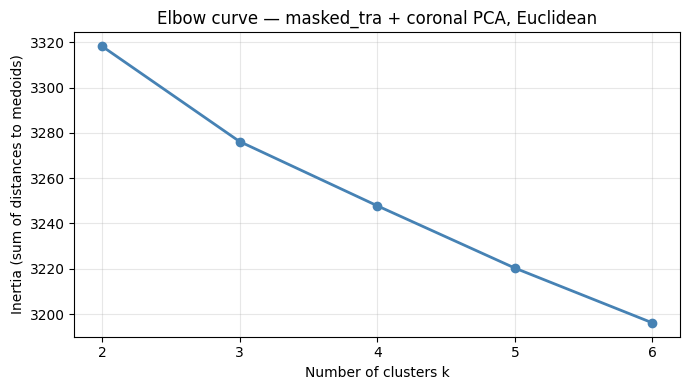

Elbow curve saved.


In [5]:
K_RANGE = range(2, 7)
losses  = []

print(f"{'k':>3}   {'inertia':>14}")
print("─" * 22)

for k in K_RANGE:
    print(f"  Fitting k={k} ...", end=" ", flush=True)
    base = kmedoids.KMedoids(
        n_clusters=k,
        metric="precomputed",
        method="pam",
        random_state=42,
    )
    model = SampleDistClustering(
        clustering_method=base,
        metric="euclidean",
        frac_sample_size=1.0,
        random_state=42,
        p1=X.shape[1],
    )
    model.fit(X)
    loss = getattr(model, "inertia_",
           getattr(model.clustering_method, "inertia_", None))
    losses.append(loss)
    print(f"inertia = {loss:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_RANGE), losses, marker="o", linewidth=2, color="steelblue")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("Inertia (sum of distances to medoids)")
ax.set_title("Elbow curve — masked_tra + coronal PCA, Euclidean")
ax.set_xticks(list(K_RANGE))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(NB_DIR, "elbow_masked_tra_cor_euclidean.png"), dpi=150)
plt.show()
print("Elbow curve saved.")

## Cell 7 — Final clustering k=3

In [6]:
K = 3

base_k3 = kmedoids.KMedoids(
    n_clusters=K,
    metric="precomputed",
    method="pam",
    random_state=42,
)
model_k3 = SampleDistClustering(
    clustering_method=base_k3,
    metric="euclidean",
    frac_sample_size=1.0,
    random_state=42,
    p1=X.shape[1],
)
print(f"Fitting k={K} ...", end=" ", flush=True)
model_k3.fit(X)
labels_k3 = np.array(model_k3.labels_, dtype=int)

inertia_k3 = getattr(model_k3, "inertia_",
             getattr(model_k3.clustering_method, "inertia_", None))
sizes_k3   = {c: int((labels_k3 == c).sum()) for c in sorted(set(labels_k3))}
print(f"done")
print(f"  Inertia       : {inertia_k3:.4f}")
print(f"  Cluster sizes : {sizes_k3}")

Fitting k=3 ... done
  Inertia       : 3276.1771
  Cluster sizes : {np.int64(0): 169, np.int64(1): 113, np.int64(2): 134}


## Cell 8 — Evaluation k=3

Crosstab vs CDR · Silhouette (all 416) · ARI and NMI (235 patients with CDR).

In [7]:
# ── Crosstab ─────────────────────────────────────────────────────────────────
df_res_k3 = pd.DataFrame({"patient_id": patient_ids, "cluster": labels_k3})
df_res_k3 = df_res_k3.merge(
    cdr_series.reset_index(), on="patient_id", how="left"
)
has_cdr_k3 = df_res_k3[df_res_k3["CDR"].notnull()].copy()
has_cdr_k3["CDR"] = has_cdr_k3["CDR"].astype(str)

print(f"k=3 — {len(has_cdr_k3)} patients with CDR\n")
ct = pd.crosstab(has_cdr_k3["cluster"], has_cdr_k3["CDR"],
                 margins=True, margins_name="Total")
print("Count:")
print(ct.to_string())
pct = pd.crosstab(has_cdr_k3["cluster"], has_cdr_k3["CDR"],
                  normalize="index").mul(100).round(1)
print("\nRow %:")
print(pct.to_string())

# ── Silhouette ────────────────────────────────────────────────────────────────
sil_k3 = silhouette_score(X, labels_k3, metric="euclidean")
print(f"\nSilhouette (k=3)  : {sil_k3:.4f}")

# ── ARI / NMI ────────────────────────────────────────────────────────────────
ari_k3 = adjusted_rand_score(cdr_int, labels_k3[mask_cdr])
nmi_k3 = normalized_mutual_info_score(cdr_int, labels_k3[mask_cdr])
print(f"ARI (k=3)         : {ari_k3:.4f}")
print(f"NMI (k=3)         : {nmi_k3:.4f}")

k=3 — 235 patients with CDR

Count:
CDR      0.0  0.5  1.0  2.0  Total
cluster                           
0         46   15    4    0     65
1         29    9    4    0     42
2         60   46   20    2    128
Total    135   70   28    2    235

Row %:
CDR       0.0   0.5   1.0  2.0
cluster                       
0        70.8  23.1   6.2  0.0
1        69.0  21.4   9.5  0.0
2        46.9  35.9  15.6  1.6

Silhouette (k=3)  : 0.0090
ARI (k=3)         : -0.0263
NMI (k=3)         : 0.0332


## Cell 9 — Final clustering k=4

In [8]:
K = 4

base_k4 = kmedoids.KMedoids(
    n_clusters=K,
    metric="precomputed",
    method="pam",
    random_state=42,
)
model_k4 = SampleDistClustering(
    clustering_method=base_k4,
    metric="euclidean",
    frac_sample_size=1.0,
    random_state=42,
    p1=X.shape[1],
)
print(f"Fitting k={K} ...", end=" ", flush=True)
model_k4.fit(X)
labels_k4 = np.array(model_k4.labels_, dtype=int)

inertia_k4 = getattr(model_k4, "inertia_",
             getattr(model_k4.clustering_method, "inertia_", None))
sizes_k4   = {c: int((labels_k4 == c).sum()) for c in sorted(set(labels_k4))}
print(f"done")
print(f"  Inertia       : {inertia_k4:.4f}")
print(f"  Cluster sizes : {sizes_k4}")

Fitting k=4 ... done
  Inertia       : 3247.8150
  Cluster sizes : {np.int64(0): 157, np.int64(1): 50, np.int64(2): 105, np.int64(3): 104}


## Cell 10 — Evaluation k=4

Crosstab vs CDR · Silhouette (all 416) · ARI and NMI (235 patients with CDR).

In [9]:
# ── Crosstab ─────────────────────────────────────────────────────────────────
df_res_k4 = pd.DataFrame({"patient_id": patient_ids, "cluster": labels_k4})
df_res_k4 = df_res_k4.merge(
    cdr_series.reset_index(), on="patient_id", how="left"
)
has_cdr_k4 = df_res_k4[df_res_k4["CDR"].notnull()].copy()
has_cdr_k4["CDR"] = has_cdr_k4["CDR"].astype(str)

print(f"k=4 — {len(has_cdr_k4)} patients with CDR\n")
ct = pd.crosstab(has_cdr_k4["cluster"], has_cdr_k4["CDR"],
                 margins=True, margins_name="Total")
print("Count:")
print(ct.to_string())
pct = pd.crosstab(has_cdr_k4["cluster"], has_cdr_k4["CDR"],
                  normalize="index").mul(100).round(1)
print("\nRow %:")
print(pct.to_string())

# ── Silhouette ────────────────────────────────────────────────────────────────
sil_k4 = silhouette_score(X, labels_k4, metric="euclidean")
print(f"\nSilhouette (k=4)  : {sil_k4:.4f}")

# ── ARI / NMI ────────────────────────────────────────────────────────────────
ari_k4 = adjusted_rand_score(cdr_int, labels_k4[mask_cdr])
nmi_k4 = normalized_mutual_info_score(cdr_int, labels_k4[mask_cdr])
print(f"ARI (k=4)         : {ari_k4:.4f}")
print(f"NMI (k=4)         : {nmi_k4:.4f}")

k=4 — 235 patients with CDR

Count:
CDR      0.0  0.5  1.0  2.0  Total
cluster                           
0         40    9    4    0     53
1         19   21    9    1     50
2         51   35   12    1     99
3         25    5    3    0     33
Total    135   70   28    2    235

Row %:
CDR       0.0   0.5   1.0  2.0
cluster                       
0        75.5  17.0   7.5  0.0
1        38.0  42.0  18.0  2.0
2        51.5  35.4  12.1  1.0
3        75.8  15.2   9.1  0.0

Silhouette (k=4)  : 0.0090
ARI (k=4)         : 0.0079
NMI (k=4)         : 0.0430


## Cell 11 — Summary table: k=3 vs k=4

In [10]:
summary = pd.DataFrame([
    {"k": 3,
     "Inertia":    round(inertia_k3, 4),
     "Silhouette": round(sil_k3,     4),
     "ARI":        round(ari_k3,     4),
     "NMI":        round(nmi_k3,     4)},
    {"k": 4,
     "Inertia":    round(inertia_k4, 4),
     "Silhouette": round(sil_k4,     4),
     "ARI":        round(ari_k4,     4),
     "NMI":        round(nmi_k4,     4)},
])

print("Masked transverse + coronal PCA (220 features) — Euclidean distance")
print("=" * 65)
print(summary.to_string(index=False))
print(f"\nSilhouette: all {len(patient_ids)} patients")
print(f"ARI / NMI : {mask_cdr.sum()} patients with CDR  (CDR × 2 integer categories)")

Masked transverse + coronal PCA (220 features) — Euclidean distance
 k   Inertia  Silhouette     ARI    NMI
 3 3276.1771       0.009 -0.0263 0.0332
 4 3247.8150       0.009  0.0079 0.0430

Silhouette: all 416 patients
ARI / NMI : 235 patients with CDR  (CDR × 2 integer categories)
